In [1]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.spatial.distance import pdist
from itertools import combinations


class DistanceTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, x_columns=range(16), y_columns=range(16, 32)):
        self.x_columns = x_columns
        self.y_columns = y_columns
        self.pairs = list(combinations(range(1, 17), 2))
        self.column_names = [f"d_{i}_{j}" for i, j in self.pairs]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        x = X.iloc[:, self.x_columns].values
        y = X.iloc[:, self.y_columns].values
        coords = np.stack((x, y), axis=2)
        distances = np.array([pdist(sample, metric='euclidean') for sample in coords])
        return pd.concat([
            X.reset_index(drop=True),
            pd.DataFrame(distances, columns=self.column_names, index=X.index).reset_index(drop=True),
        ], axis=1)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = []
        return np.array(list(input_features) + self.column_names)

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder


def create_nn_pipeline(numeric_cols, location_col='location'):
    numeric_pipeline = Pipeline([
        ("dist", DistanceTransformer(x_columns=numeric_cols[:16], y_columns=numeric_cols[16:32])),
        ("num", StandardScaler())
    ])

    pipeline = Pipeline([
        ("preprocessor", ColumnTransformer(transformers=[
            ('num', numeric_pipeline, numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), [location_col]),
        ], remainder="passthrough"))
    ])
    return pipeline


def create_tree_pipeline(x_cols=range(16), y_cols=range(16, 32), location_col='location'):
    pipeline = Pipeline([
        ('preprocessor', ColumnTransformer(transformers=[
            ("cat", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), [location_col]),
            ("dist", DistanceTransformer(x_columns=x_cols, y_columns=y_cols), list(x_cols) + list(y_cols))
        ], remainder='passthrough'))
    ])
    return pipeline

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split


def data_loading(path, location):
    df = pd.read_csv(path, header=None)
    rename_cols = lambda col: (
        f'x{c + 1}' if (c := int(col)) < 16 else
        f'y{c % 16 + 1}' if c < 32 else
        f'p{c % 16 + 1}' if c < 48 else
        f'total_power'
    )
    df.rename(columns=rename_cols, inplace=True)
    df['location'] = location

    return df


def data_split(df):
    X = df.drop(df.columns[32:49], axis=1)
    y = df.iloc[:, 32:49]

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    return X_train, X_val, X_test, y_train, y_val, y_test


df = pd.concat([
    data_loading(path='data/raw/Adelaide_Data.csv', location='Adelaide'),
    data_loading(path='data/raw/Perth_Data.csv', location='Perth'),
    data_loading(path='data/raw/Sydney_Data.csv', location='Sydney'),
    data_loading(path='data/raw/Tasmania_Data.csv', location='Tasmania'),
])

# Raw data (best for Linear Regression, Ridge, Lasso)
X_train, X_val, X_test, y_train, y_val, y_test = data_split(df)

# Create pipelines
nn_pipeline = create_nn_pipeline(numeric_cols=list(range(0, 32)))
tree_pipeline = create_tree_pipeline(x_cols=range(16), y_cols=range(16, 32))

# Data with one-hot encoding, scaling, and pairwise-distances (best for Neural Networks)
nn_X_train = pd.DataFrame(nn_pipeline.fit_transform(X_train), columns=nn_pipeline.get_feature_names_out())
nn_X_val = pd.DataFrame(nn_pipeline.transform(X_val), columns=nn_pipeline.get_feature_names_out())
nn_X_test = pd.DataFrame(nn_pipeline.transform(X_test), columns=nn_pipeline.get_feature_names_out())

# Data with only ordinal encoding (best for Decision Trees, Random Forest, Gradient Boosting models)
tree_X_train = pd.DataFrame(tree_pipeline.fit_transform(X_train), columns=tree_pipeline.get_feature_names_out())
tree_X_val = pd.DataFrame(tree_pipeline.transform(X_val), columns=tree_pipeline.get_feature_names_out())
tree_X_test = pd.DataFrame(tree_pipeline.transform(X_test), columns=tree_pipeline.get_feature_names_out())

print("Raw features shape:", X_train.shape)
print("NN features shape:", nn_X_train.shape)
print("Tree features shape:", tree_X_train.shape)

Raw features shape: (230399, 33)
NN features shape: (230399, 156)
Tree features shape: (230399, 153)


# Visualizations

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
x1,287999.0,3.033614e+02,1.901123e+02,0.000000e+00,1.258082e+02,3.259884e+02,4.808997e+02,5.660000e+02
x2,287999.0,2.888290e+02,1.861985e+02,0.000000e+00,1.182549e+02,2.955663e+02,4.591079e+02,5.660000e+02
x3,287999.0,2.854713e+02,1.914871e+02,0.000000e+00,1.014796e+02,2.953504e+02,4.618632e+02,5.660000e+02
x4,287999.0,2.702581e+02,1.901820e+02,0.000000e+00,9.172270e+01,2.612055e+02,4.443037e+02,5.660000e+02
x5,287999.0,3.083923e+02,1.837539e+02,0.000000e+00,1.440969e+02,3.247872e+02,4.767441e+02,5.660000e+02
x6,287999.0,2.590163e+02,1.955984e+02,0.000000e+00,7.033230e+01,2.385402e+02,4.455955e+02,5.660000e+02
x7,287999.0,2.676938e+02,1.884894e+02,0.000000e+00,9.259815e+01,2.509009e+02,4.442544e+02,5.660000e+02
x8,287999.0,2.814400e+02,1.828069e+02,0.000000e+00,1.168579e+02,2.807679e+02,4.485785e+02,5.660000e+02
x9,287999.0,2.786783e+02,1.864688e+02,0.000000e+00,1.087951e+02,2.750159e+02,4.526396e+02,5.660000e+02
x10,287999.0,2.793135e+02,1.883202e+02,0.000000e+00,1.050472e+02,2.798851e+02,4.528669e+02,5.660000e+02


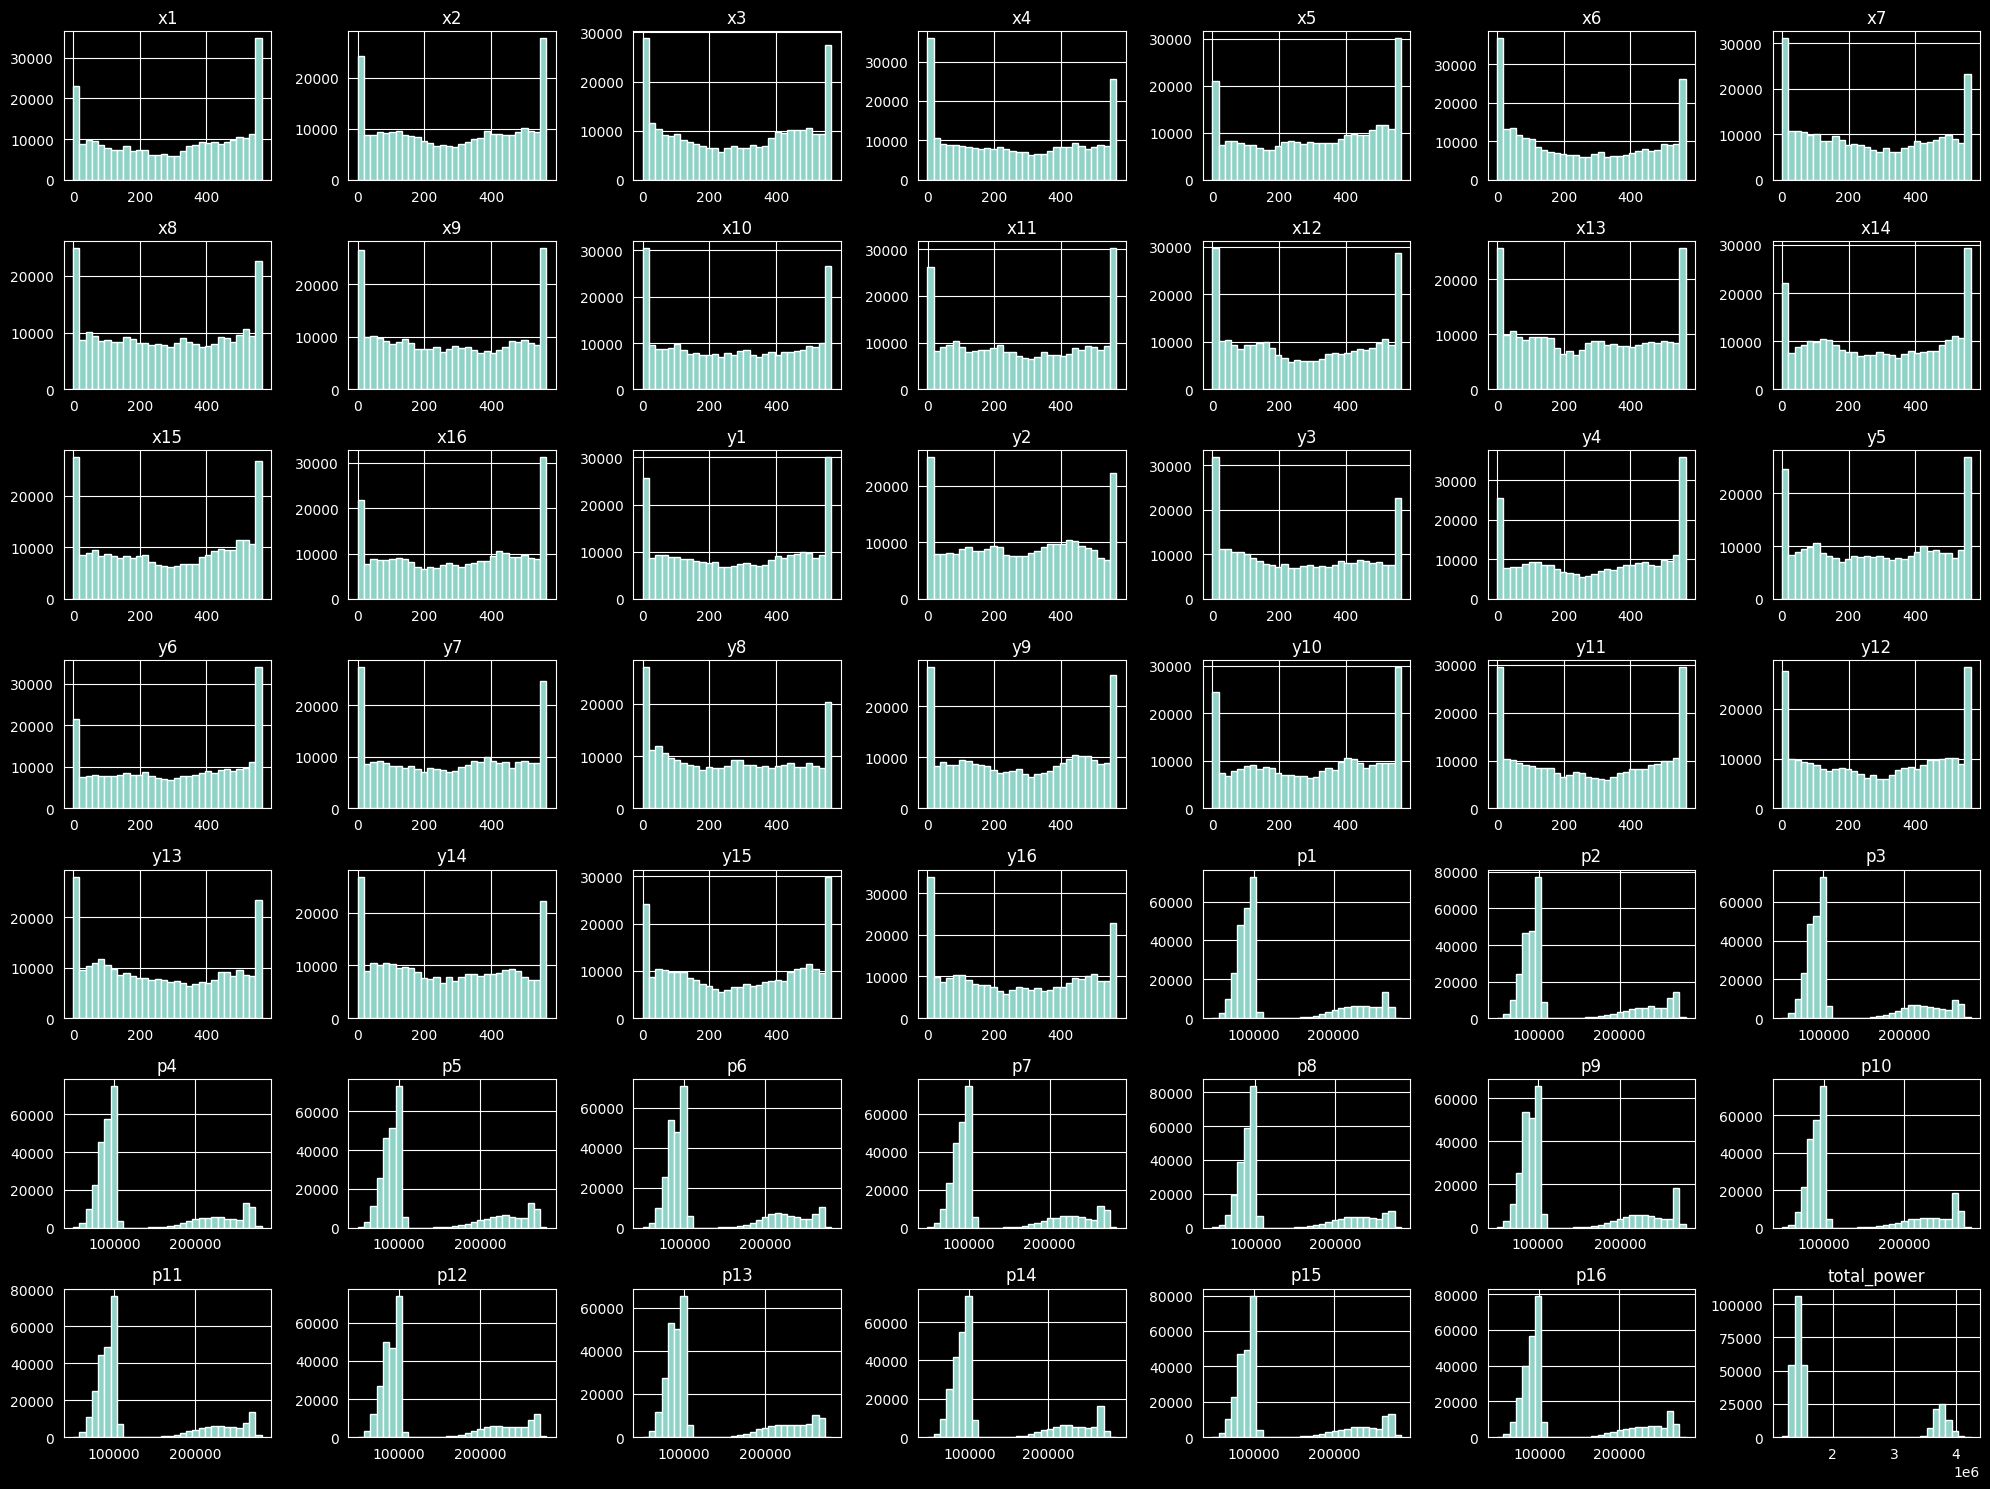

In [15]:
df.hist(figsize=(20,15), bins=30)
plt.tight_layout()
plt.show()

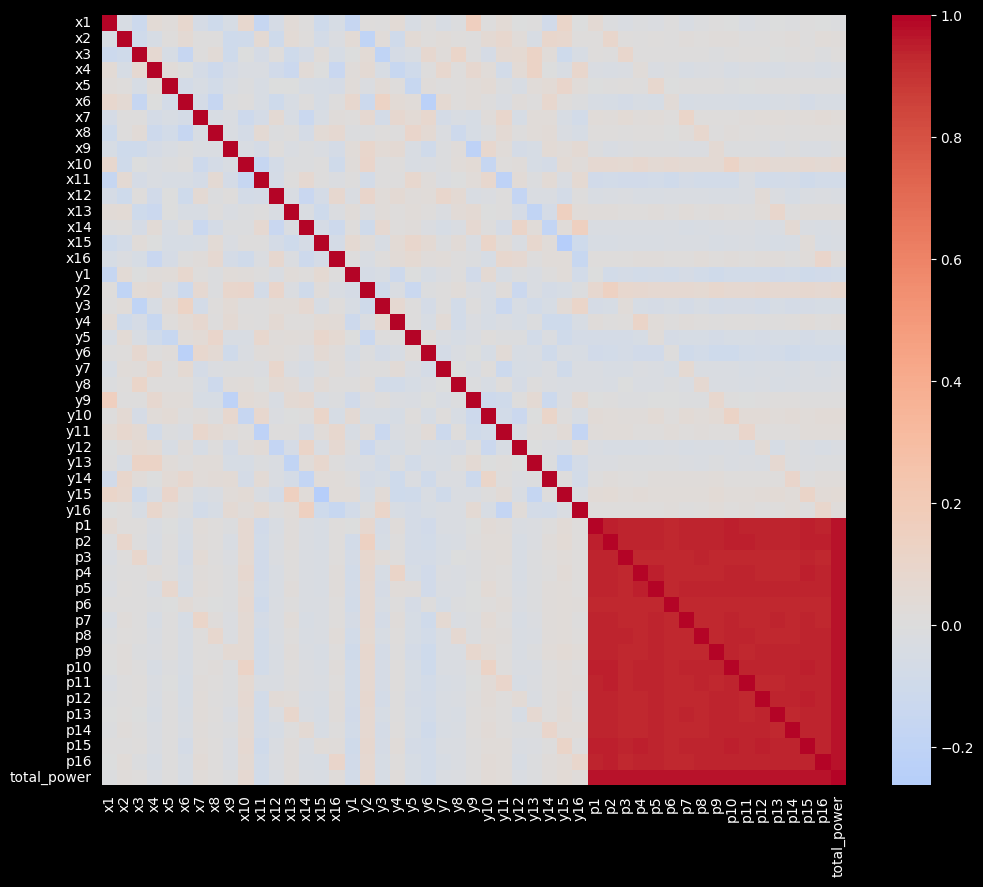

In [19]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.show()

## Layout Scatter Plot

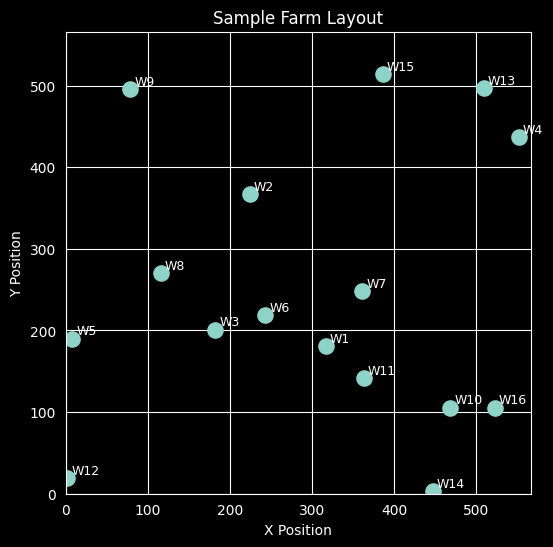

In [10]:
row = df.iloc[0]

x = row[0:16]
y = row[16:32]

plt.figure(figsize=(6,6))
plt.xlim(0, 566)
plt.ylim(0, 566)

plt.scatter(x, y, s=120)
for i, (xi, yi) in enumerate(zip(x, y), start=1):
    plt.text(xi + 5, yi + 5, f"W{i}", fontsize=9)

plt.title("Sample Farm Layout")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.show()

# Data Visualization with single dataset

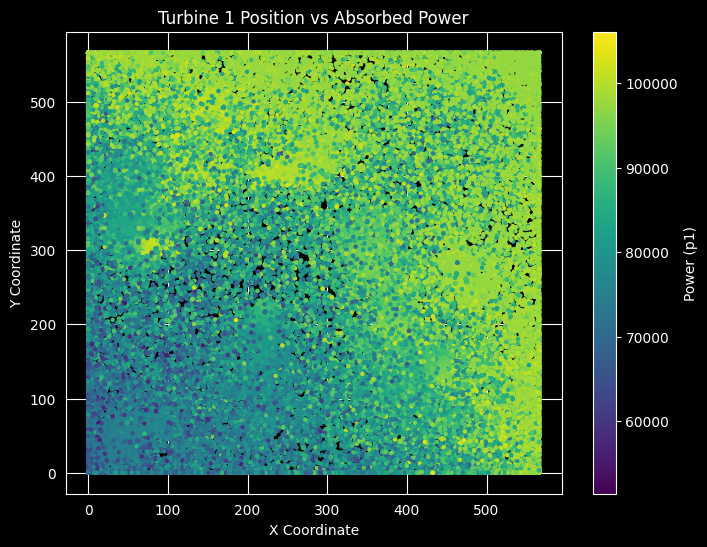

In [15]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(df["x1"], df["y1"],
                 c=df["p1"],
                 cmap="viridis",
                 s=5)

plt.colorbar(sc, label="Power (p1)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Turbine 1 Position vs Absorbed Power")
plt.show()

# Data Visualization with all four datasets

In [10]:
long_df = pd.wide_to_long(
    df.reset_index(),
    stubnames=['x', 'y', 'p'],
    i=['index', 'location'],
    j='turbine',
    sep='',
    suffix='\d+'
).reset_index()

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1386/3230381020.py:7: SyntaxWarning: invalid escape sequence '\d'
  suffix='\d+'


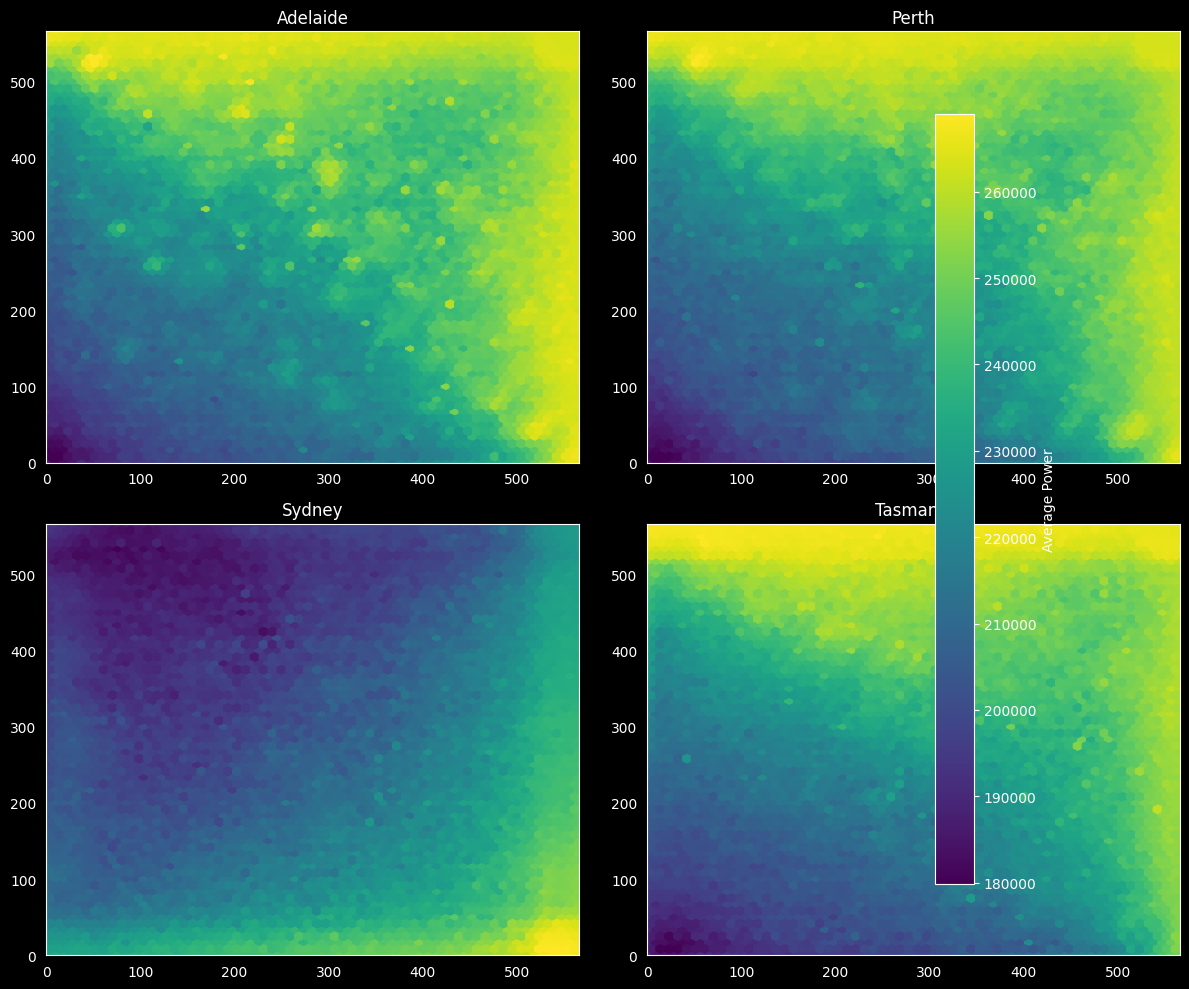

In [11]:
locations = long_df["location"].unique()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, loc in zip(axes.flatten(), locations):
    subset = long_df[long_df["location"] == loc]

    hb = ax.hexbin(subset["x"], subset["y"],
                   C=subset["p"],
                   gridsize=60,
                   cmap="viridis")

    ax.set_title(loc)
    ax.set_xlim(0, 566)
    ax.set_ylim(0, 566)

fig.colorbar(hb, ax=axes.ravel().tolist(), label="Average Power")
plt.tight_layout()
plt.show()

## Histogram of total power per location

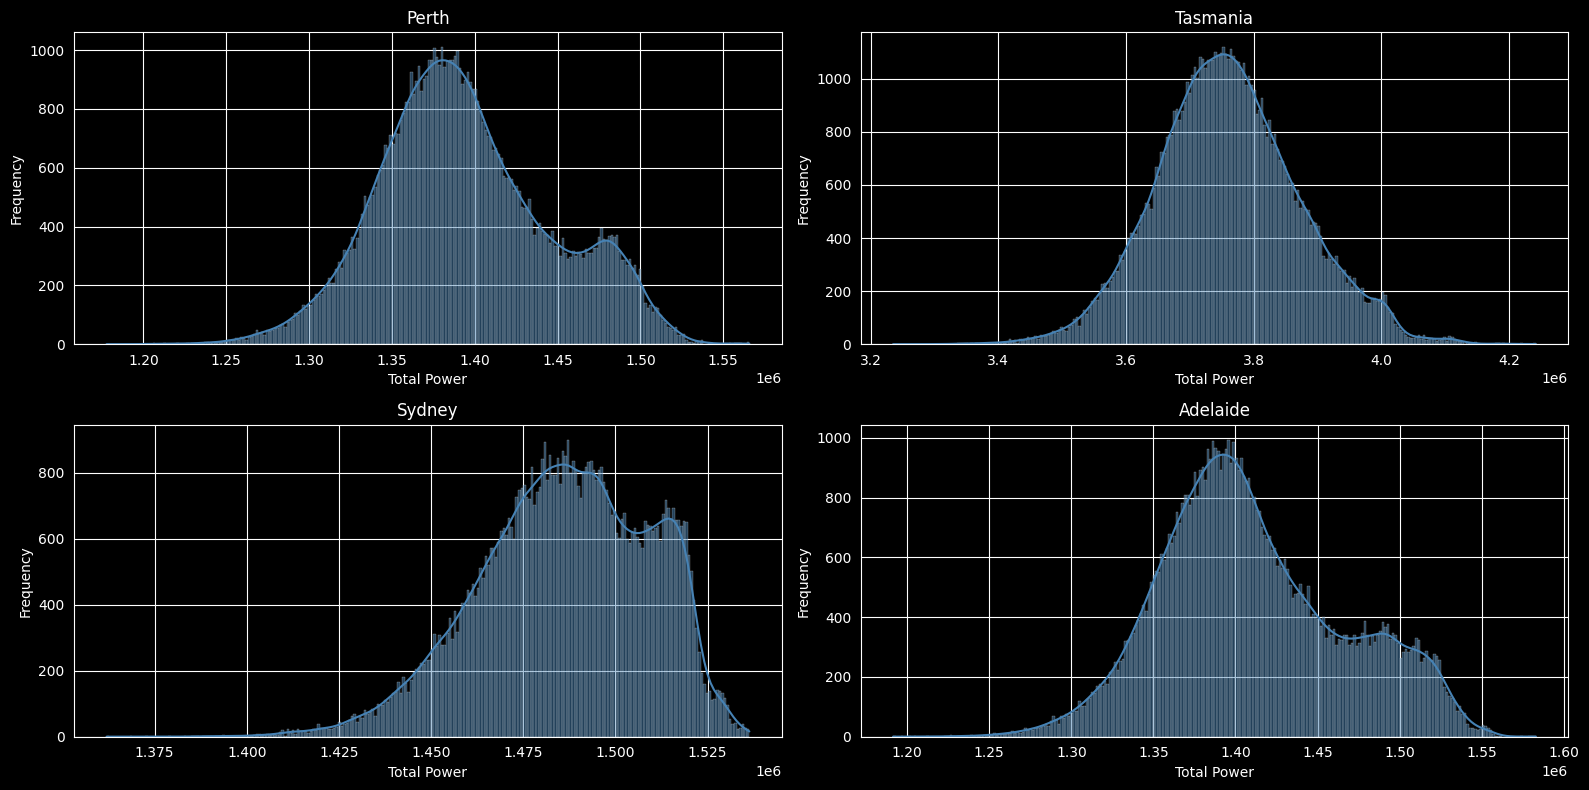

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

locations = X_train["location"].unique()

n_cols = 2
n_rows = (len(locations) + n_cols - 1) // n_cols

plt.figure(figsize=(16, 4*n_rows))

for i, loc in enumerate(locations):
    plt.subplot(n_rows, n_cols, i+1)
    
    subset = df[df["location"] == loc]
    
    sns.histplot(
        subset["total_power"],
        bins=250,
        kde=True,
        color="steelblue"
    )
    
    plt.title(loc)
    plt.xlabel("Total Power")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Pairwise distance vs Total power

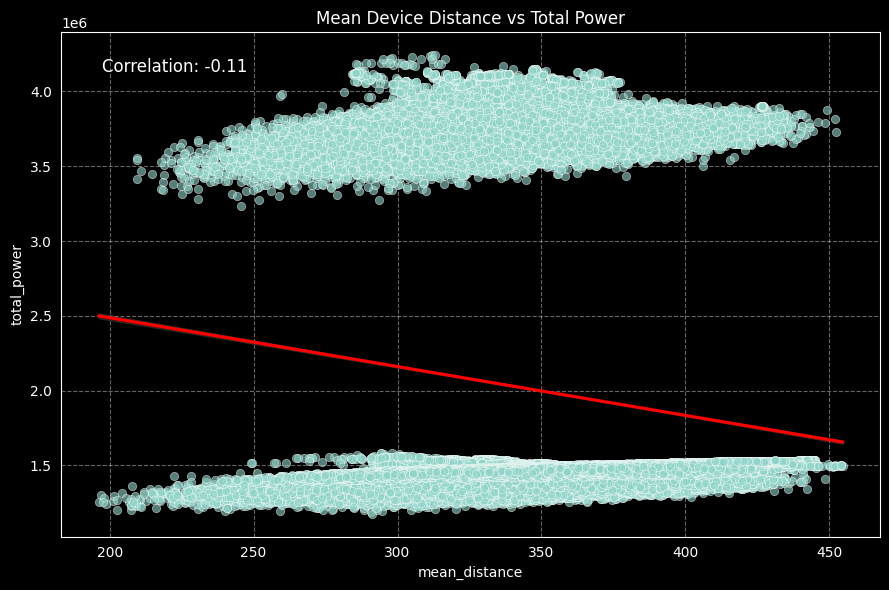

In [37]:
def mean_distance(row):
    coords = [(row[f"x{i}"], row[f"y{i}"]) for i in range(1,17)]
    return np.mean(pdist(coords))

df["mean_distance"] = df.apply(mean_distance, axis=1)

corr = df["mean_distance"].corr(df["total_power"])

plt.figure(figsize=(9,6))

sns.scatterplot(data=df, x="mean_distance", y="total_power", alpha=0.6)
sns.regplot(data=df, x="mean_distance", y="total_power", scatter=False, color="red")

plt.text(
    0.05, 0.95,
    f"Correlation: {corr:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

plt.title("Mean Device Distance vs Total Power")

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Spatial power map

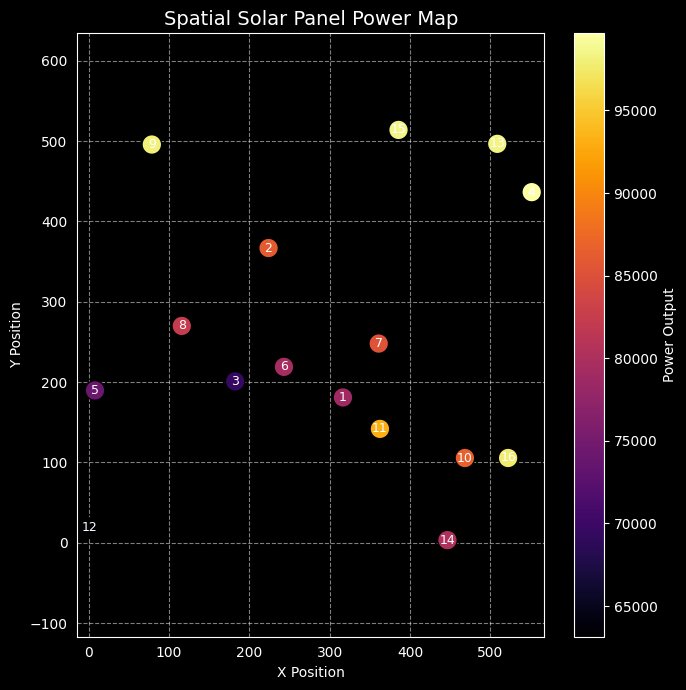

In [30]:
import matplotlib.pyplot as plt
import numpy as np

row = df.iloc[0]

x = np.array([row[f"x{i}"] for i in range(1,17)])
y = np.array([row[f"y{i}"] for i in range(1,17)])
p = np.array([row[f"p{i}"] for i in range(1,17)])

plt.figure(figsize=(7,7))

scatter = plt.scatter(
    x, y,
    c=p,
    cmap="inferno",
    s=200,
    edgecolor="black"
)

# Label each point
for i in range(len(x)):
    plt.text(x[i], y[i], str(i+1), ha='center', va='center', color='white', fontsize=9)

plt.colorbar(scatter, label="Power Output")

plt.title("Spatial Solar Panel Power Map", fontsize=14)
plt.xlabel("X Position")
plt.ylabel("Y Position")

plt.grid(True, linestyle="--", alpha=0.5)
plt.axis("equal")

plt.tight_layout()
plt.show()

## Location comparison

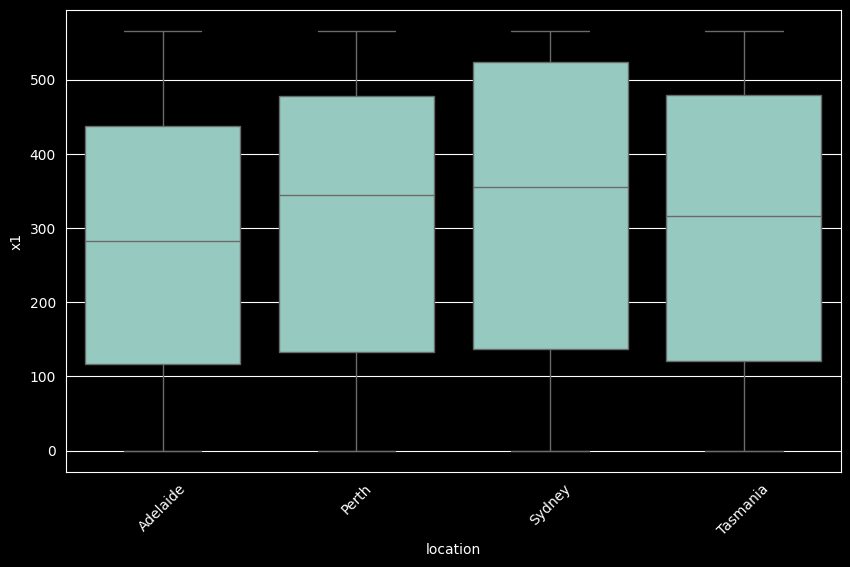

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='location', y='x1')
plt.xticks(rotation=45)
plt.show()

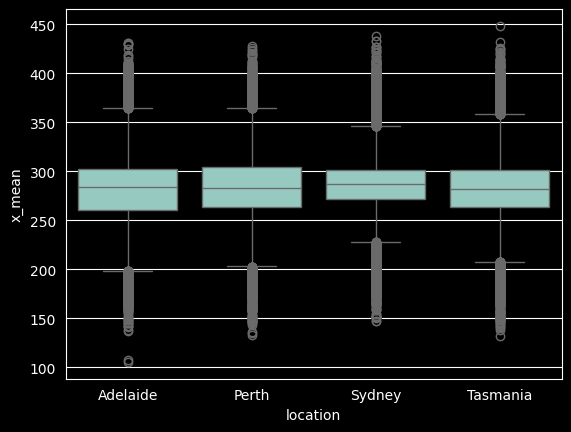

In [25]:
df['x_mean'] = df[[col for col in df.columns if col.startswith('x')]].mean(axis=1)
df['y_mean'] = df[[col for col in df.columns if col.startswith('y')]].mean(axis=1)

sns.boxplot(data=df, x='location', y='x_mean')
plt.show()

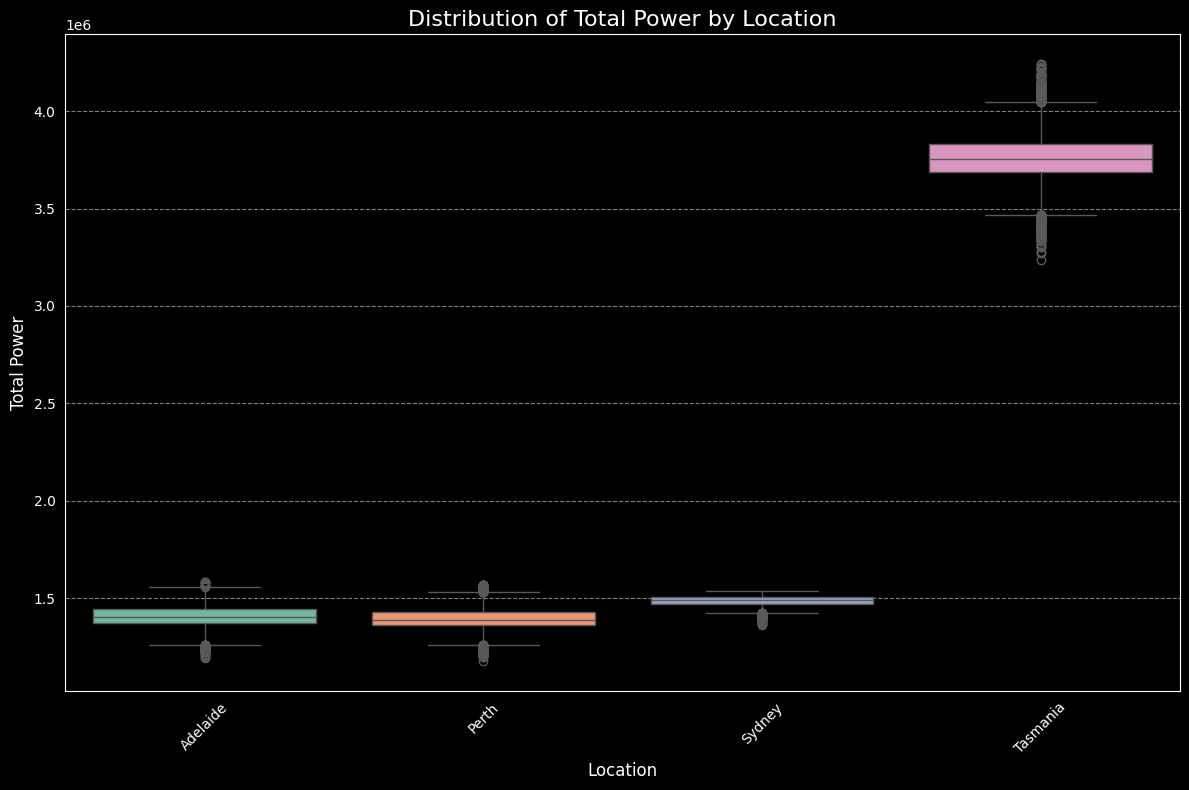

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.boxplot(
    data=df,
    x="location",
    y="total_power",
    palette="Set2",
    showfliers=True
)

plt.xticks(rotation=45)
plt.title("Distribution of Total Power by Location", fontsize=16)
plt.xlabel("Location", fontsize=12)
plt.ylabel("Total Power", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## PCA Visualization

In [18]:
from sklearn.decomposition import PCA

coord_cols = [f"x{i}" for i in range(1,17)] + [f"y{i}" for i in range(1,17)]

X = df[coord_cols]

pca = PCA(n_components=2)
components = pca.fit_transform(X)

pca_df = pd.DataFrame(components, columns=["PC1","PC2"])
pca_df["power"] = df["total_power"]

plt.figure(figsize=(7,5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="power", palette="viridis")
plt.title("PCA of Farm Layouts")
plt.show()

ValueError: cannot reindex on an axis with duplicate labels

## Farm Layout Density Heatmap

In [ ]:
all_x = []
all_y = []

for _, row in df.iterrows():
    for i in range(1,17):
        all_x.append(row[f"x{i}"])
        all_y.append(row[f"y{i}"])

plt.figure(figsize=(6,6))
sns.kdeplot(x=all_x, y=all_y, cmap="Reds", fill=True)
plt.title("Density of Device Positions")
plt.show()

## Layout vs Power Animation

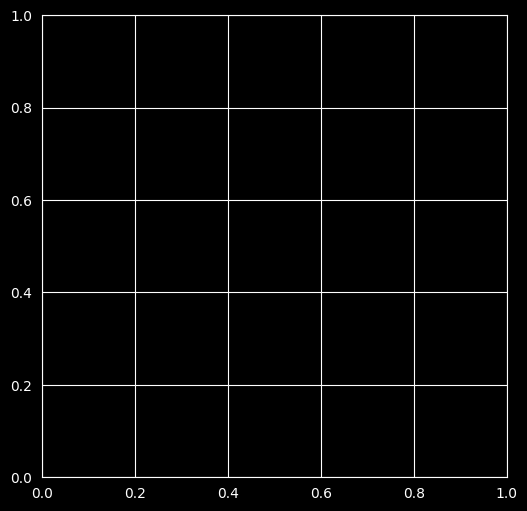

In [17]:
import matplotlib.animation as animation

df_sorted = df.sort_values("total_power")

fig, ax = plt.subplots(figsize=(6,6))

def update(frame):
    ax.clear()
    row = df_sorted.iloc[frame]

    x = [row[f"x{i}"] for i in range(1,17)]
    y = [row[f"y{i}"] for i in range(1,17)]

    ax.scatter(x, y, s=120)
    ax.set_title(f"Power: {row['total_power']:.2f}")

ani = animation.FuncAnimation(fig, update, frames=50)

plt.show()

## Network graph of WEC farm

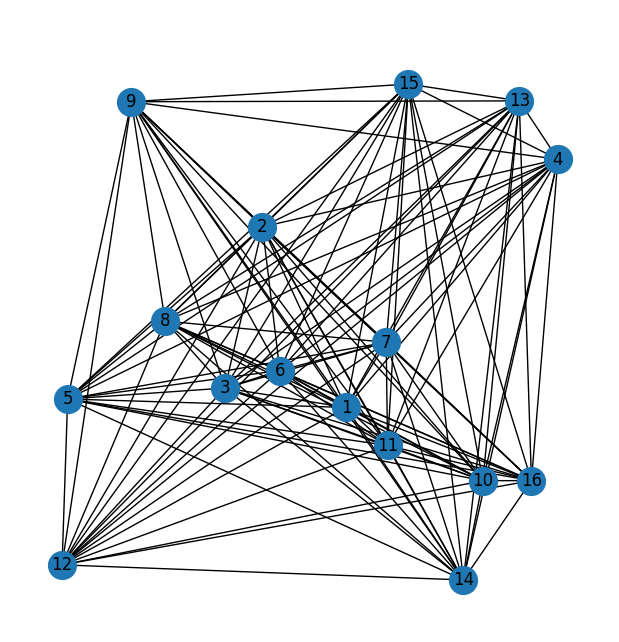

In [17]:
import networkx as nx

row = df.iloc[0]

G = nx.Graph()

coords = {}

for i in range(1,17):
    coords[i] = (row[f"x{i}"], row[f"y{i}"])
    G.add_node(i)

for i in range(1,17):
    for j in range(i+1,17):
        dist = np.linalg.norm(np.array(coords[i]) - np.array(coords[j]))
        G.add_edge(i, j, weight=dist)

plt.figure(figsize=(6,6))
nx.draw(G, pos=coords, with_labels=True, node_size=400)
plt.title("WEC Farm Interaction Network")
plt.show()

## Power gradient map

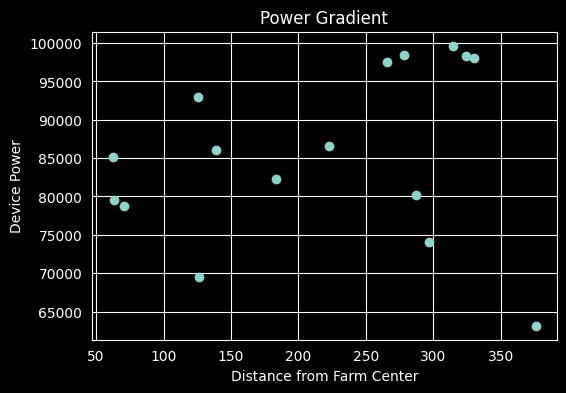

In [16]:
row = df.iloc[0]

x = np.array([row[f"x{i}"] for i in range(1,17)])
y = np.array([row[f"y{i}"] for i in range(1,17)])
p = np.array([row[f"p{i}"] for i in range(1,17)])

center_x = x.mean()
center_y = y.mean()

dist = np.sqrt((x-center_x)**2 + (y-center_y)**2)

plt.figure(figsize=(6,4))
plt.scatter(dist, p)
plt.xlabel("Distance from Farm Center")
plt.ylabel("Device Power")
plt.title("Power Gradient")
plt.show()

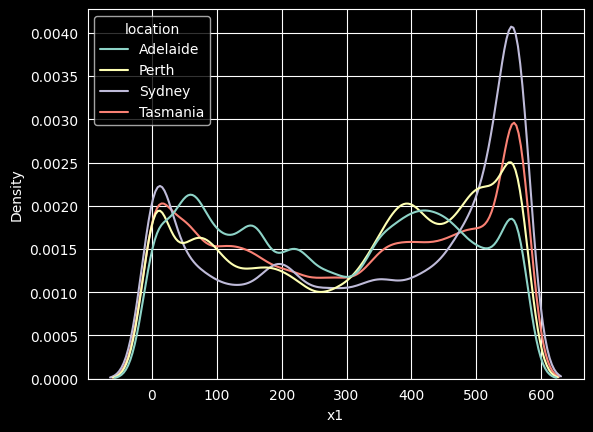

In [23]:
sns.kdeplot(data=df, x='x1', hue='location', common_norm=False)
plt.show()

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df.select_dtypes(include='number')
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pca_df['location'] = df['location']

sns.scatterplot(data=pca_df.sample(5000),
                x='PC1', y='PC2',
                hue='location', alpha=0.6)
plt.show()

ValueError: cannot reindex on an axis with duplicate labels

In [26]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

sns.scatterplot(data=pca_df.sample(5000),
                x='PC1', y='PC2',
                hue=df['cluster'])
plt.show()

ValueError: cannot reindex on an axis with duplicate labels

In [27]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.01)
df['anomaly'] = iso.fit_predict(X_scaled)

In [28]:
df.skew(numeric_only=True).sort_values(ascending=False)

p7             1.261179
p4             1.259619
p3             1.258014
p6             1.256941
p8             1.252903
p9             1.252882
p12            1.247629
p11            1.246510
p13            1.246020
p10            1.243292
p15            1.242849
p5             1.241966
p14            1.241761
p1             1.241268
p16            1.236743
p2             1.228971
total_power    1.155834
x6             0.174561
y3             0.121961
y13            0.121243
x7             0.107393
y8             0.091943
y14            0.085712
x4             0.066325
y16            0.052778
x9             0.047740
x13            0.040553
x12            0.039680
x11            0.025052
x10            0.017476
cluster        0.016011
x8             0.007731
y11            0.001775
x_mean        -0.000885
x14           -0.001206
y5            -0.009413
y_mean        -0.020922
y7            -0.032978
y9            -0.033585
y2            -0.034136
x2            -0.036775
y12           -0

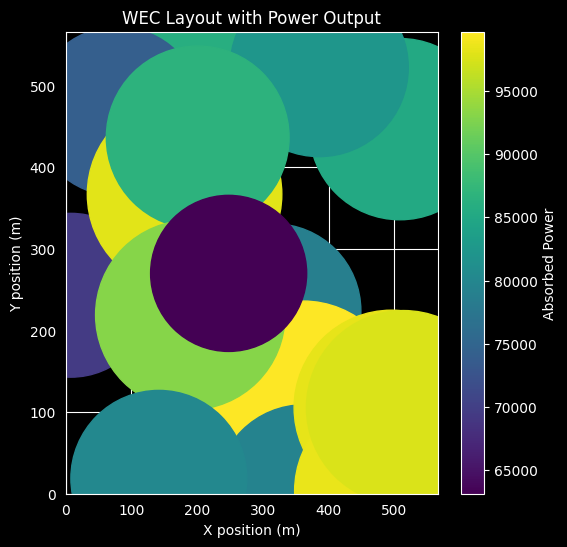

In [8]:
power = row[32:48]  # P1 ... P16

plt.figure(figsize=(6, 6))
sc = plt.scatter(x, y, c=power, s=power/5, cmap="viridis")

plt.colorbar(sc, label="Absorbed Power")
plt.xlim(0, 566)
plt.ylim(0, 566)
plt.xlabel("X position (m)")
plt.ylabel("Y position (m)")
plt.title("WEC Layout with Power Output")
plt.grid(True)
plt.show()

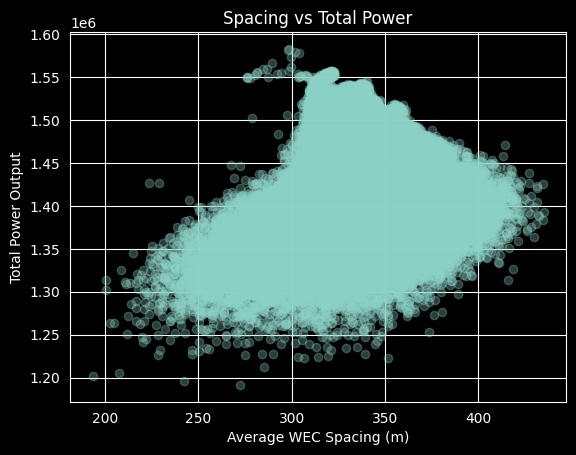

In [12]:
import numpy as np
from scipy.spatial.distance import pdist

def avg_spacing(row):
    coords = np.column_stack((row[0:32:2], row[1:32:2]))
    return pdist(coords).mean()

df["avg_spacing"] = df.apply(avg_spacing, axis=1)

plt.scatter(df["avg_spacing"], df[48], alpha=0.3)
plt.xlabel("Average WEC Spacing (m)")
plt.ylabel("Total Power Output")
plt.title("Spacing vs Total Power")
plt.show()